In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
os.makedirs("figures", exist_ok=True)

CLASS_PALETTE = {"French": "#e05c5c", "LMU": "#5c8de0", "Dunn": "#5cc97e"}
CLASS_LABELS  = {"French": "Lung Cancer", "LMU": "Benign Disease", "Dunn": "Healthy"}

In [2]:
DATA_DIR = "data/preprocessed_data"

X_df  = pd.read_csv(os.path.join(DATA_DIR, "data_matrix_norm.csv"), index_col=0)
meta  = pd.read_csv(os.path.join(DATA_DIR, "retained_samples.csv"))
feats = pd.read_csv(os.path.join(DATA_DIR, "retained_features.csv"))

meta  = meta.set_index("sample").loc[X_df.index].reset_index()
y     = meta["class"].values
le    = LabelEncoder()
y_enc = le.fit_transform(y)
X     = X_df.values

classes   = ["Dunn", "French", "LMU"]
group_idx = {c: np.where(y == c)[0] for c in classes}

print(f"Data matrix : {X_df.shape}  (samples x features)")
print(f"Class counts: {pd.Series(y).value_counts().to_dict()}")

Data matrix : (75, 133)  (samples x features)
Class counts: {'Dunn': 26, 'French': 26, 'LMU': 23}


We will try three methods to find the most important features for biomarker discovery:
1. **T-tests** (pairwise, FDR-corrected) - statistical significance and effect size per contrast
2. **LASSO Logistic Regression** - sparse feature selection
3. **Random Forest** (permutation importance) - non-linear, model-based predictive ranking

The three evidence streams are combined into a consensus score to produce a final hierarchical biomarker list.

## 1. Pairwise t-tests + FDR Correction

All three contrasts are tested independently with BH FDR control at 5 % (we need p-value correction since we have $\sim$ 130 features and therefore $\sim$ 130 tests).
The t-test null hypothesis is that we have equal means, so rejecting the hypothesis is saying we don't have statistically significant equality, however we also need to estimate how much different are the means so we use Cohen'd.

Cohen's d is used as the effect-size measure: `d = (mean1 - mean2) / s_pooled` (How many standard deviations apart are the two groups?) |d| >= 0.2 small, >= 0.5 medium, >= 0.8 large.

In [3]:
PAIRS = [
    ("French", "Dunn", "Cancer vs Healthy"),
    ("French", "LMU",  "Cancer vs Benign"),
    ("LMU",    "Dunn", "Benign vs Healthy"),
]

def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2) / (na+nb-2))
    return (a.mean() - b.mean()) / pooled if pooled > 0 else 0.0

ttest_results = {}
for c1, c2, label in PAIRS:
    idx1, idx2 = group_idx[c1], group_idx[c2]
    rows = []
    for feat in X_df.columns:
        v1, v2 = X_df[feat].values[idx1], X_df[feat].values[idx2]
        t, p   = ttest_ind(v1, v2, equal_var=False)
        d      = cohens_d(v1, v2)
        rows.append({"feature": feat, "t": t, "p_raw": p, "cohens_d": d})
    df_pair = pd.DataFrame(rows)
    _, p_adj, _, _ = multipletests(df_pair["p_raw"], method="fdr_bh")
    df_pair["p_adj"] = p_adj
    df_pair["sig"]   = p_adj < 0.05
    ttest_results[(c1, c2)] = df_pair.sort_values("p_adj")
    n_sig   = df_pair["sig"].sum()
    n_large = (df_pair["cohens_d"].abs() >= 0.8).sum()
    print(f"{label:28s}  FDR-sig: {n_sig:3d} / {len(df_pair)}   large |d|>=0.8: {n_large}")

Cancer vs Healthy             FDR-sig:  98 / 133   large |d|>=0.8: 84
Cancer vs Benign              FDR-sig: 103 / 133   large |d|>=0.8: 100
Benign vs Healthy             FDR-sig:  93 / 133   large |d|>=0.8: 78


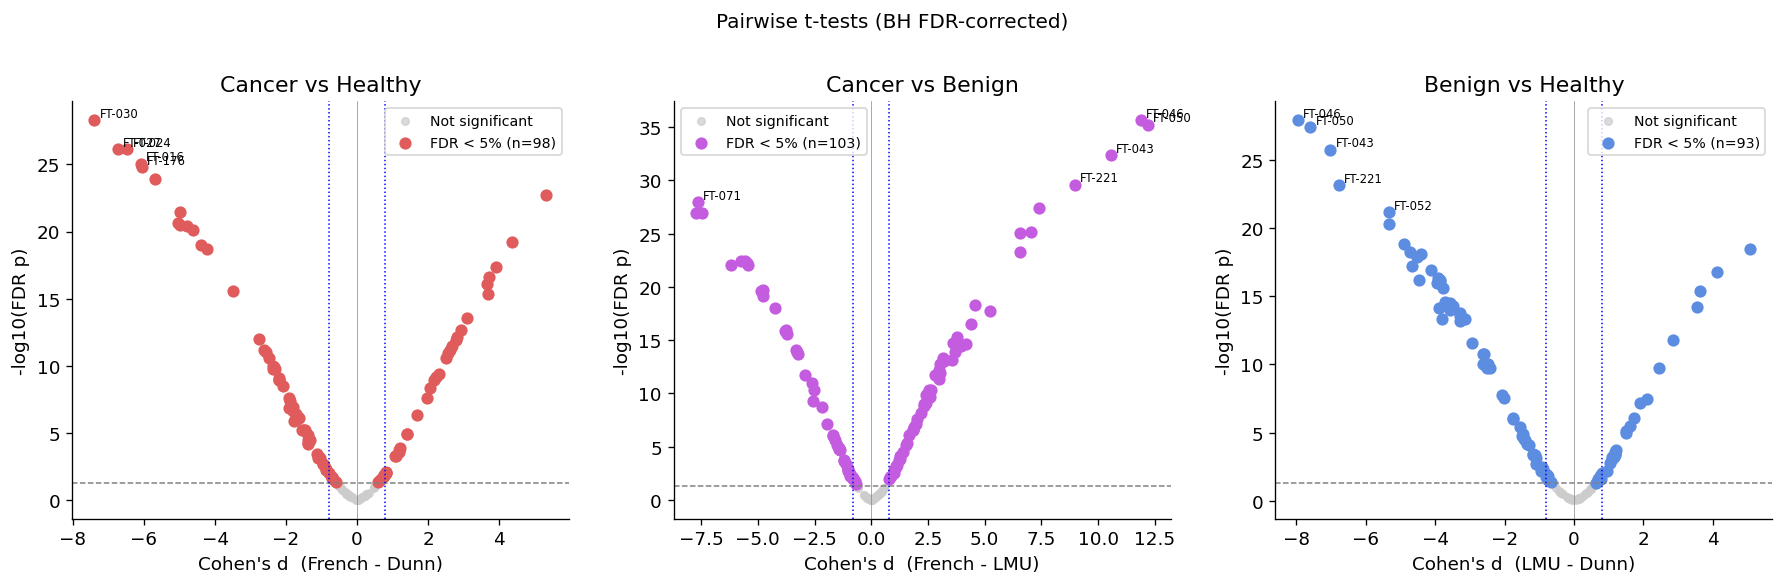

In [4]:
PAIR_COLORS = {
    ("French", "Dunn"): "#e05c5c",
    ("French", "LMU"):  "#c45ce0",
    ("LMU",    "Dunn"): "#5c8de0",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, (c1, c2, label) in zip(axes, PAIRS):
    df_v = ttest_results[(c1, c2)]
    sig  = df_v["sig"]

    ax.scatter(df_v.loc[~sig, "cohens_d"], -np.log10(df_v.loc[~sig, "p_adj"]),
               c="#cccccc", s=20, alpha=0.7, label="Not significant")
    ax.scatter(df_v.loc[sig,  "cohens_d"], -np.log10(df_v.loc[sig,  "p_adj"]),
               c=PAIR_COLORS[(c1, c2)], s=40, label=f"FDR < 5% (n={sig.sum()})")

    for _, row in df_v.head(5).iterrows():
        ax.annotate(row["feature"],
                    (row["cohens_d"], -np.log10(row["p_adj"])),
                    fontsize=7, xytext=(3, 2), textcoords="offset points")

    ax.axhline(-np.log10(0.05), color="grey", ls="--", lw=0.9)
    ax.axvline(0, color="grey", lw=0.4)
    ax.axvline( 0.8, color="blue", ls=":", lw=0.9)
    ax.axvline(-0.8, color="blue", ls=":", lw=0.9)
    ax.set_xlabel(f"Cohen's d  ({c1} - {c2})")
    ax.set_ylabel("-log10(FDR p)")
    ax.set_title(label)
    ax.legend(fontsize=8.5)

plt.suptitle("Pairwise t-tests (BH FDR-corrected)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [5]:
sig_overlap = pd.DataFrame({
    "Cancer vs Healthy": ttest_results[("French","Dunn")].set_index("feature")["sig"],
    "Cancer vs Benign":  ttest_results[("French","LMU") ].set_index("feature")["sig"],
    "Benign vs Healthy": ttest_results[("LMU","Dunn")   ].set_index("feature")["sig"],
}).fillna(False).astype(int)
sig_overlap["n_contrasts"] = sig_overlap.sum(axis=1)

from collections import Counter
cols   = ["Cancer vs Healthy", "Cancer vs Benign", "Benign vs Healthy"]
combos = Counter(tuple(r) for r in sig_overlap[cols].values)
print("Significance overlap  (Cancer vs Healthy | Cancer vs Benign | Benign vs Healthy):")
for combo, cnt in sorted(combos.items(), key=lambda x: -sum(x[0])):
    pattern = "  |  ".join(["sig" if v else " - " for v in combo])
    print(f"  [ {pattern} ]  ->  {cnt} features")

all3 = sig_overlap[sig_overlap["n_contrasts"] == 3].index.tolist()
print(f"\nSignificant in ALL 3 contrasts: {len(all3)}")

d_matrix = pd.DataFrame({
    "d_CvH": ttest_results[("French","Dunn")].set_index("feature")["cohens_d"],
    "d_CvB": ttest_results[("French","LMU") ].set_index("feature")["cohens_d"],
    "d_BvH": ttest_results[("LMU","Dunn")   ].set_index("feature")["cohens_d"],
})
max_abs_d = d_matrix.abs().max(axis=1).rename("max_abs_d")
print(f"Features with max |d| >= 0.8 (large effect): {(max_abs_d >= 0.8).sum()}")

Significance overlap  (Cancer vs Healthy | Cancer vs Benign | Benign vs Healthy):
  [ sig  |  sig  |  sig ]  ->  56 features
  [ sig  |   -   |  sig ]  ->  12 features
  [ sig  |  sig  |   -  ]  ->  24 features
  [  -   |  sig  |  sig ]  ->  21 features
  [ sig  |   -   |   -  ]  ->  6 features
  [  -   |   -   |  sig ]  ->  4 features
  [  -   |  sig  |   -  ]  ->  2 features
  [  -   |   -   |   -  ]  ->  8 features

Significant in ALL 3 contrasts: 56
Features with max |d| >= 0.8 (large effect): 116


## 2. LASSO Logistic Regression

L1 regularisation drives irrelevant feature coefficients to exactly zero.

We sweep the regularisation strength *C* (inverse of penalty; lower C = stronger shrinkage) and select the value that maximises cross-validated balanced accuracy.

Features with any non-zero coefficient in the optimal model are considered selected.

coefficient magnitude reflects their discriminatory strength.

Best C = 0.0621  |  CV balanced accuracy = 1.000  |  selected features = 10


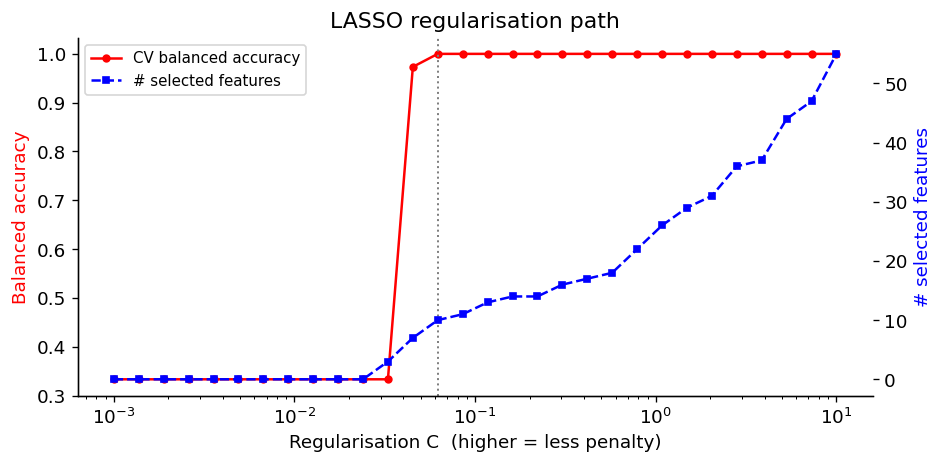

In [18]:
C_grid = np.logspace(-3, 1, 30)
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc_lasso, n_nonzeros = [], []
for C in C_grid:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(penalty="l1", C=C, solver="saga",
                                   max_iter=5000, class_weight="balanced",
                                   multi_class="multinomial", random_state=42)),
    ])
    acc = cross_val_score(pipe, X, y, cv=cv, scoring="balanced_accuracy").mean()
    pipe.fit(X, y)
    n_nonzero = (pipe.named_steps["lr"].coef_ != 0).any(axis=0).sum()
    cv_acc_lasso.append(acc)
    n_nonzeros.append(n_nonzero)
    
best_idx = int(np.argmax(cv_acc_lasso))
best_C   = C_grid[best_idx]
print(f"Best C = {best_C:.4f}  |  CV balanced accuracy = {cv_acc_lasso[best_idx]:.3f}"
      f"  |  selected features = {n_nonzeros[best_idx]}")

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.semilogx(C_grid, cv_acc_lasso, color="red", marker="o", ms=4,
             label="CV balanced accuracy")
ax2.semilogx(C_grid, n_nonzeros,    color="blue", marker="s", ms=4, ls="--",
             label="# selected features")
ax1.axvline(best_C, color="grey", ls=":", lw=1.2)
ax1.set_xlabel("Regularisation C  (higher = less penalty)")
ax1.set_ylabel("Balanced accuracy", color="red")
ax2.set_ylabel("# selected features", color="blue")
ax1.set_title("LASSO regularisation path")
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=9)
plt.tight_layout()
plt.savefig("figures/lasso_path.png", bbox_inches="tight", dpi=150)
plt.show()

The weight magnitude corresponds to the corresponding feature importance to the logistic regression model to decide its classification

LASSO selected 10 / 133 features

Top 10 by coefficient magnitude:
feature  lasso_selected  lasso_max_coef
 FT-030            True        0.626386
 FT-043            True        0.274672
 FT-221            True        0.263572
 FT-050            True        0.202055
 FT-046            True        0.188622
 FT-016            True        0.167124
 FT-176            True        0.160715
 FT-021            True        0.071293
 FT-140            True        0.038684
 FT-037            True        0.031009


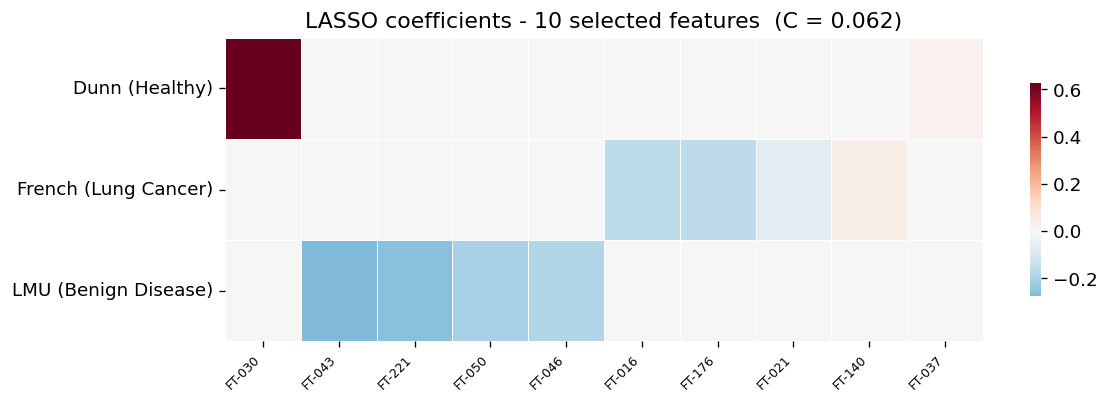

In [7]:
scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X)

lr_best = LogisticRegression(penalty="l1", C=best_C, solver="saga",
                              max_iter=5000, class_weight="balanced",
                              multi_class="multinomial", random_state=42)
lr_best.fit(X_sc, y)

coef_mat       = lr_best.coef_                   # (3 classes, n_features)
lasso_selected = (coef_mat != 0).any(axis=0)
lasso_max_coef = np.abs(coef_mat).max(axis=0)

lasso_df = pd.DataFrame({
    "feature":        X_df.columns,
    "lasso_selected": lasso_selected,
    "lasso_max_coef": lasso_max_coef,
}).sort_values("lasso_max_coef", ascending=False)

print(f"LASSO selected {lasso_selected.sum()} / {len(X_df.columns)} features")
print(f"\nTop 10 by coefficient magnitude:")
print(lasso_df.head(10).to_string(index=False))

# Coefficient heatmap
sel_feats = lasso_df[lasso_df["lasso_selected"]]["feature"].tolist()
col_order = lasso_df[lasso_df["lasso_selected"]].sort_values(
    "lasso_max_coef", ascending=False)["feature"].tolist()
coef_sel  = pd.DataFrame(coef_mat, index=le.classes_, columns=X_df.columns)[col_order]

fig, ax = plt.subplots(figsize=(max(10, len(sel_feats)*0.38), 3.5))
sns.heatmap(coef_sel, cmap="RdBu_r", center=0, ax=ax,
            xticklabels=True, yticklabels=True,
            linewidths=0.3, cbar_kws={"shrink": 0.7})
ax.set_yticklabels([f"{c} ({CLASS_LABELS[c]})" for c in le.classes_], rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7.5)
ax.set_title(f"LASSO coefficients - {len(sel_feats)} selected features  (C = {best_C:.3f})")
plt.tight_layout()
plt.savefig("figures/lasso_coefs.png", bbox_inches="tight", dpi=150)
plt.show()

## 3. Random Forest - Permutation Importance

Random Forest aggregates many decision trees, capturing non-linear interactions between features.
Permutation importance (50 repeats) measures how much the model's balanced accuracy drops when a
feature's values are randomly shuffled: a high drop signals a genuinely informative feature.

In [8]:
np.random.seed(42)
rf = RandomForestClassifier(n_estimators=100, max_features="sqrt",
                             class_weight="balanced", random_state=42, n_jobs=-1)
scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X)
rf.fit(X_sc, y)

pipe_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(n_estimators=100, max_features="sqrt",
                                   class_weight="balanced",
                                   random_state=42, n_jobs=-1)),
])
rf_cv = cross_val_score(pipe_rf, X, y, cv=cv, scoring="balanced_accuracy")
print(f"Random Forest CV balanced accuracy: {rf_cv.mean():.3f} +/- {rf_cv.std():.3f}")

perm = permutation_importance(rf, X_sc, y, n_repeats=50, random_state=42, n_jobs=-1, scoring="balanced_accuracy")
rf_imp_df = pd.DataFrame({
    "feature":     X_df.columns,
    "rf_imp_mean": perm.importances_mean,
    "rf_imp_std":  perm.importances_std,
}).sort_values("rf_imp_mean", ascending=False)

print(f"\nTop 15 features by permutation importance:")
print(rf_imp_df.head(15)[["feature","rf_imp_mean","rf_imp_std"]].to_string(index=False))

Random Forest CV balanced accuracy: 1.000 +/- 0.000

Top 15 features by permutation importance:
feature  rf_imp_mean  rf_imp_std
 FT-151          0.0         0.0
 FT-217          0.0         0.0
 FT-134          0.0         0.0
 FT-207          0.0         0.0
 FT-241          0.0         0.0
 FT-021          0.0         0.0
 FT-202          0.0         0.0
 FT-027          0.0         0.0
 FT-024          0.0         0.0
 FT-218          0.0         0.0
 FT-175          0.0         0.0
 FT-102          0.0         0.0
 FT-020          0.0         0.0
 FT-089          0.0         0.0
 FT-237          0.0         0.0


For some reason we got 0 permutation importance on all features, so we're not going to consider random forests and permutation importance for our final ranking.

## 4. Consensus Ranking and Hierarchical Biomarker List

To combine the methods used (except random forest and permutation importance) we're going to normalise their scores to the interval [0,1] using min-max normalization and take the mean of the scores.

Consensus score = arithmetic mean of the normalised components.

Features are assigned to a **tier** based on corroborating evidence:
- **Tier 1 - Core discriminators**: top-95th quartile consensus AND significant in >= 2 t-test contrasts AND LASSO-selected
- **Tier 2 - Supporting markers**: significant in >= 2 contrasts OR LASSO-selected
- **Tier 3 - Exploratory candidates**: remaining features with any t-test signal

In [19]:
def minmax(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0

candidate_feats = sig_overlap[sig_overlap["n_contrasts"] >= 1].index.tolist()
print(f"Candidate features (significant in >= 1 contrast): {len(candidate_feats)}")

score_df = pd.DataFrame(index=X_df.columns)
score_df["max_abs_d"]   = max_abs_d
score_df["lasso_coef"]  = lasso_df.set_index("feature")["lasso_max_coef"]
score_df["lasso_sel"]   = lasso_df.set_index("feature")["lasso_selected"]
score_df["n_contrasts"] = sig_overlap["n_contrasts"]
score_df = score_df.loc[candidate_feats].copy()

score_df["norm_d"]     = minmax(score_df["max_abs_d"])
score_df["norm_lasso"] = minmax(score_df["lasso_coef"])
score_df["consensus"]  = score_df[["norm_d", "norm_lasso"]].mean(axis=1)
score_df = score_df.sort_values("consensus", ascending=False)

q95 = score_df["consensus"].quantile(0.95)

def assign_tier(row):
    if row["consensus"] >= q95 and row["n_contrasts"] >= 2 and row["lasso_sel"]:
        return "Tier 1 - Core discriminators"
    elif row["n_contrasts"] >= 2 or row["lasso_sel"]:
        return "Tier 2 - Supporting markers"
    else:
        return "Tier 3 - Exploratory candidates"

score_df["tier"] = score_df.apply(assign_tier, axis=1)
score_df = score_df.reset_index().rename(columns={"index": "feature"})
score_df = score_df.merge(feats[["feature","mz"]], on="feature", how="left")
score_df.index = range(1, len(score_df)+1)

print("\nTier distribution:")
print(score_df["tier"].value_counts().sort_index().to_string())
print(f"\nTop 15 features:")
print(score_df.head(15)[
    ["feature","mz","tier","consensus","max_abs_d","n_contrasts","lasso_sel"]
].to_string())

Candidate features (significant in >= 1 contrast): 125

Tier distribution:
tier
Tier 1 - Core discriminators         7
Tier 2 - Supporting markers        106
Tier 3 - Exploratory candidates     12

Top 15 features:
   feature           mz                          tier  consensus  max_abs_d  n_contrasts  lasso_sel
1   FT-030   943.640776  Tier 1 - Core discriminators   0.792998   7.395620            3       True
2   FT-050  1004.669624  Tier 1 - Core discriminators   0.661286  12.199013            3       True
3   FT-043  1005.172042  Tier 1 - Core discriminators   0.649499  10.580435            3       True
4   FT-046  1004.167127  Tier 1 - Core discriminators   0.636812  11.879910            3       True
5   FT-221  1005.675606  Tier 1 - Core discriminators   0.571051   8.965678            3       True
6   FT-176   871.097203  Tier 1 - Core discriminators   0.435006   7.714002            3       True
7   FT-016   870.594720  Tier 1 - Core discriminators   0.428248   7.438482          

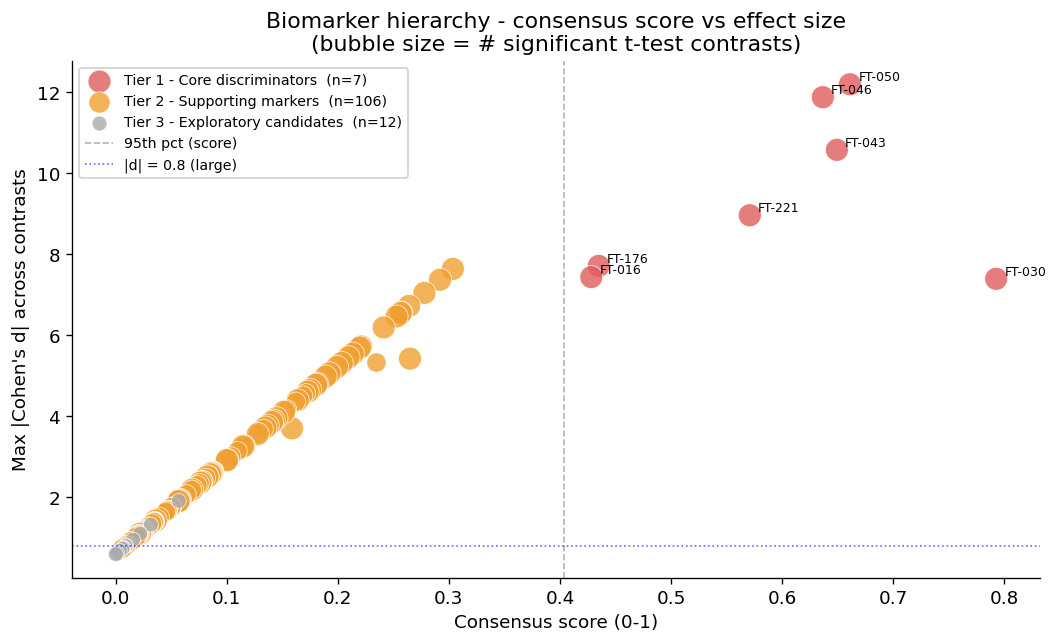

In [20]:
TIER_COLORS = {
    "Tier 1 - Core discriminators":   "#e05c5c",
    "Tier 2 - Supporting markers":     "#f0a030",
    "Tier 3 - Exploratory candidates": "#aaaaaa",
}

fig, ax = plt.subplots(figsize=(9, 5.5))
for tier, grp in score_df.groupby("tier"):
    ax.scatter(
        grp["consensus"], grp["max_abs_d"],
        s=grp["n_contrasts"] * 55 + 25,
        c=TIER_COLORS[tier], alpha=0.8,
        edgecolors="white", lw=0.5,
        label=f"{tier}  (n={len(grp)})",
    )

for _, row in score_df[score_df["tier"] == "Tier 1 - Core discriminators"].iterrows():
    ax.annotate(row["feature"],
                (row["consensus"], row["max_abs_d"]),
                fontsize=7.5, xytext=(5, 2), textcoords="offset points")

ax.axvline(q95, color="grey", ls="--", lw=1, alpha=0.6, label="95th pct (score)")
ax.axhline(0.8, color="blue", ls=":", lw=1, alpha=0.6, label="|d| = 0.8 (large)")
ax.set_xlabel("Consensus score (0-1)")
ax.set_ylabel("Max |Cohen's d| across contrasts")
ax.set_title("Biomarker hierarchy - consensus score vs effect size\n"
             "(bubble size = # significant t-test contrasts)")
ax.legend(fontsize=8.5, framealpha=0.9)
plt.tight_layout()
plt.savefig("figures/biomarker_hierarchy.png", bbox_inches="tight", dpi=150)
plt.show()

Let's check the distribution of log1p normalised intensity for the tier 1 features per class. Since they have high discriminatory power, we should get non-overlapping distributions.

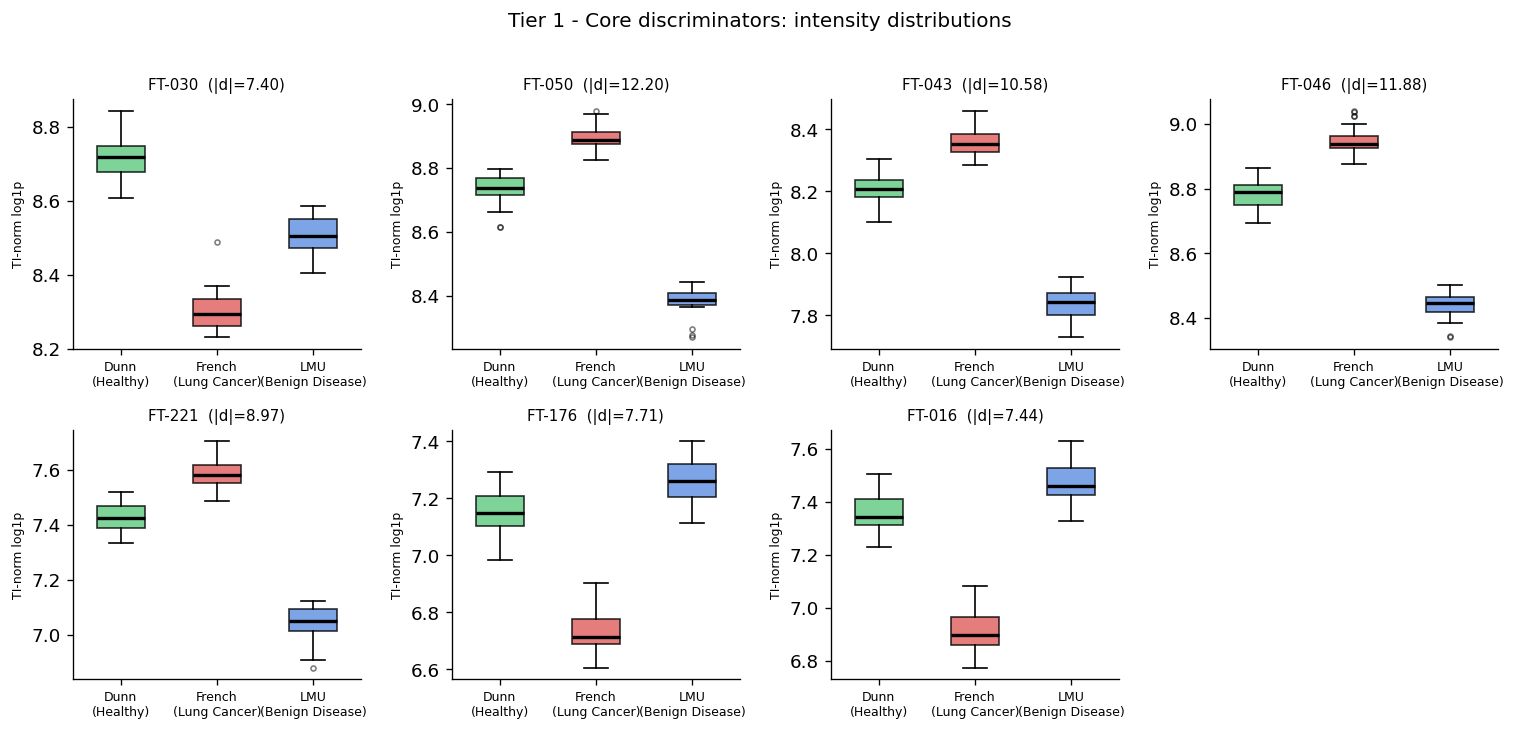

In [21]:
tier1_feats  = score_df[score_df["tier"] == "Tier 1 - Core discriminators"]["feature"].tolist()
n_tier1      = len(tier1_feats)
ncols        = min(4, n_tier1)
nrows        = int(np.ceil(n_tier1 / ncols)) if n_tier1 > 0 else 1
class_order  = ["Dunn", "French", "LMU"]
xtick_labels = [f"{c}\n({CLASS_LABELS[c]})" for c in class_order]

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.0))
axes = np.array(axes).flatten() if n_tier1 > 1 else [axes]

for ax, feat in zip(axes, tier1_feats):
    data = [X_df[feat].values[group_idx[c]] for c in class_order]
    bp   = ax.boxplot(data, patch_artist=True, widths=0.5,
                      medianprops=dict(color="black", lw=2),
                      flierprops=dict(marker="o", ms=3, alpha=0.5))
    for patch, cls in zip(bp["boxes"], class_order):
        patch.set_facecolor(CLASS_PALETTE[cls])
        patch.set_alpha(0.8)
    ax.set_xticks(range(1, 4))
    ax.set_xticklabels(xtick_labels, fontsize=7.5)
    row_info = score_df[score_df["feature"] == feat].iloc[0]
    ax.set_title(f"{feat}  (|d|={row_info['max_abs_d']:.2f})", fontsize=9)
    ax.set_ylabel("TI-norm log1p", fontsize=7.5)

for ax in axes[n_tier1:]:
    ax.set_visible(False)

plt.suptitle("Tier 1 - Core discriminators: intensity distributions",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("figures/tier1_boxplots.png", bbox_inches="tight", dpi=150)
plt.show()

## 5. Final Summary

We rank our features according to their consensus scores and we get a final ranking.

In [22]:
export_cols = ["feature", "mz", "tier", "consensus",
               "max_abs_d", "norm_d", "norm_lasso",
               "lasso_sel", "n_contrasts"]
final_table = score_df[export_cols].copy()
final_table.index = range(1, len(final_table) + 1)
final_table.to_csv("data/preprocessed_data/discriminatory_features.csv")

sym = lambda f: "Y" if f else "-"

print(f"  {'Rk':<4} {'Feature':<9} {'m/z':>9}  {'|d|':>5}  {'Score':>6}  "
      f"{'nCon':>5}  {'LASSO':>6}  Tier")
print("-" * 75)
for rank, row in final_table.iterrows():
    print(f"  {rank:<4} {row['feature']:<9} {row['mz']:>9.2f}  "
          f"{row['max_abs_d']:>5.2f}  {row['consensus']:>6.3f}  "
          f"{int(row['n_contrasts']):>5}  {sym(row['lasso_sel']):>6}  {row['tier']}")

print()
print("Performance summary:")
print(f"  LASSO  CV balanced accuracy : {cv_acc_lasso[best_idx]:.3f}"
      f"  ({n_nonzeros[best_idx]} features selected)")
print("\nTier summary:")
for t, cnt in final_table["tier"].value_counts().sort_index().items():
    print(f"  {t}: {cnt} features")
print("\nSaved: data/preprocessed_data/discriminatory_features.csv")

  Rk   Feature         m/z    |d|   Score   nCon   LASSO  Tier
---------------------------------------------------------------------------
  1    FT-030       943.64   7.40   0.793      3       Y  Tier 1 - Core discriminators
  2    FT-050      1004.67  12.20   0.661      3       Y  Tier 1 - Core discriminators
  3    FT-043      1005.17  10.58   0.649      3       Y  Tier 1 - Core discriminators
  4    FT-046      1004.17  11.88   0.637      3       Y  Tier 1 - Core discriminators
  5    FT-221      1005.68   8.97   0.571      3       Y  Tier 1 - Core discriminators
  6    FT-176       871.10   7.71   0.435      3       Y  Tier 1 - Core discriminators
  7    FT-016       870.59   7.44   0.428      3       Y  Tier 1 - Core discriminators
  8    FT-071      1150.75   7.64   0.304      3       -  Tier 2 - Supporting markers
  9    FT-067      1150.25   7.37   0.292      3       -  Tier 2 - Supporting markers
  10   FT-070      1150.75   7.05   0.278      3       -  Tier 2 - Supporting ma